In [18]:
import torch 
import torch.nn as nn 
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
# transforms 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5,))
])

# loading MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

In [20]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        # flatten
        x = x.view(x.size(0), -1)

        # latent representation
        latent = self.encoder(x)

        # reconstruct input
        reconstructed = self.decoder(latent)

        # reshape to original dimensions
        reconstructed = reconstructed.view(x.size(0), 1, 28, 28)
        return reconstructed

In [21]:
model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        outputs = model(images)
        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

Epoch [1/20], Average Loss: 0.1389
Epoch [2/20], Average Loss: 0.0666
Epoch [3/20], Average Loss: 0.0527
Epoch [4/20], Average Loss: 0.0455
Epoch [5/20], Average Loss: 0.0415
Epoch [6/20], Average Loss: 0.0390
Epoch [7/20], Average Loss: 0.0372
Epoch [8/20], Average Loss: 0.0357
Epoch [9/20], Average Loss: 0.0346
Epoch [10/20], Average Loss: 0.0336
Epoch [11/20], Average Loss: 0.0328
Epoch [12/20], Average Loss: 0.0322
Epoch [13/20], Average Loss: 0.0315
Epoch [14/20], Average Loss: 0.0310
Epoch [15/20], Average Loss: 0.0305
Epoch [16/20], Average Loss: 0.0301
Epoch [17/20], Average Loss: 0.0297
Epoch [18/20], Average Loss: 0.0294
Epoch [19/20], Average Loss: 0.0290
Epoch [20/20], Average Loss: 0.0288


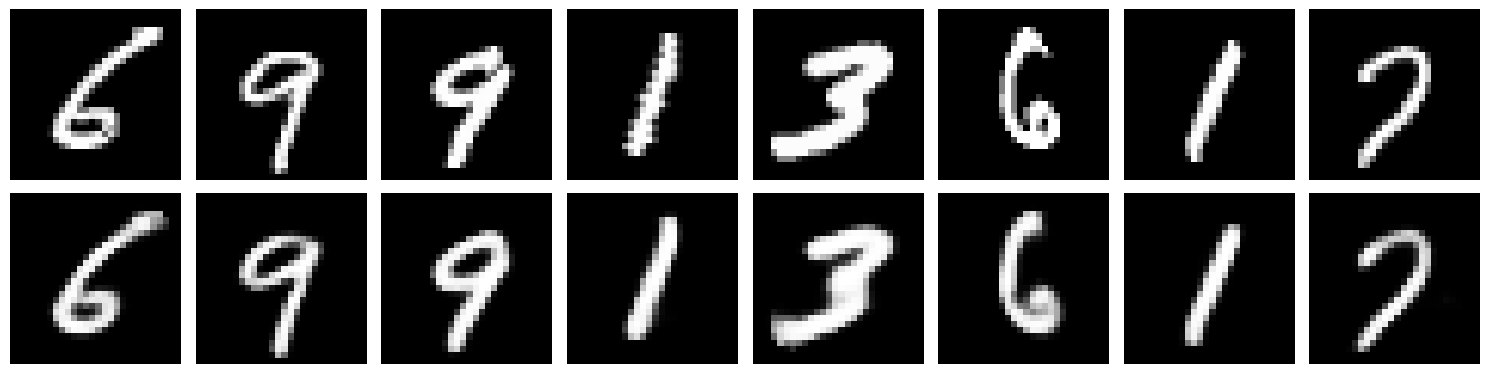

In [22]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, data_loader):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(data_loader))
        images = images.to(device)
        reconstructed = model(images)

        fig, axes = plt.subplots(2, 8, figsize=(15, 4))
        for i in range(8):

            # original
            axes[0,i].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
            axes[0,i].axis('off')

            # reconstructed 
            axes[1,i].imshow(reconstructed[i].cpu().numpy().squeeze(), cmap='gray')
            axes[1,i].axis('off')

        plt.tight_layout()
        plt.show()

# Visualize results
visualize_reconstruction(model, train_loader)

In [23]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import torchvision 
import torchvision.transforms as transforms 
import matplotlib.pyplot as plt

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [49]:
batch_size=128
lr = 1e-3
epochs=20
noise=0.4

In [50]:
def add_noise(x, noise=0.4):
    noise = noise * torch.rand_like(x)
    # print(noise)
    noisy = x + noise
    # print(noisy)
    # print(torch.clamp(noisy, 0. ,1.))
    return torch.clamp(noisy, 0. ,1.)

tensor = torch.rand(2,2)
tensor

add_noise(tensor)

tensor([[0.2442, 0.3098],
        [1.0000, 0.9506]])

In [51]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # encoder 
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), # 14x14 -> 7x7
            nn.ReLU()
        )

        # decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, 2, 1, 1),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

model = DenoisingAutoencoder().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr)

In [52]:
for epoch in range(epochs):
    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)
        noisy_images = add_noise(images, noise)

        outputs = model(noisy_images)
        loss = loss_fn(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/20] Loss: 0.0333
Epoch [2/20] Loss: 0.0069
Epoch [3/20] Loss: 0.0061
Epoch [4/20] Loss: 0.0057
Epoch [5/20] Loss: 0.0054
Epoch [6/20] Loss: 0.0052
Epoch [7/20] Loss: 0.0050
Epoch [8/20] Loss: 0.0049
Epoch [9/20] Loss: 0.0048
Epoch [10/20] Loss: 0.0047
Epoch [11/20] Loss: 0.0046
Epoch [12/20] Loss: 0.0045
Epoch [13/20] Loss: 0.0045
Epoch [14/20] Loss: 0.0044
Epoch [15/20] Loss: 0.0044
Epoch [16/20] Loss: 0.0043
Epoch [17/20] Loss: 0.0043
Epoch [18/20] Loss: 0.0043
Epoch [19/20] Loss: 0.0042
Epoch [20/20] Loss: 0.0042


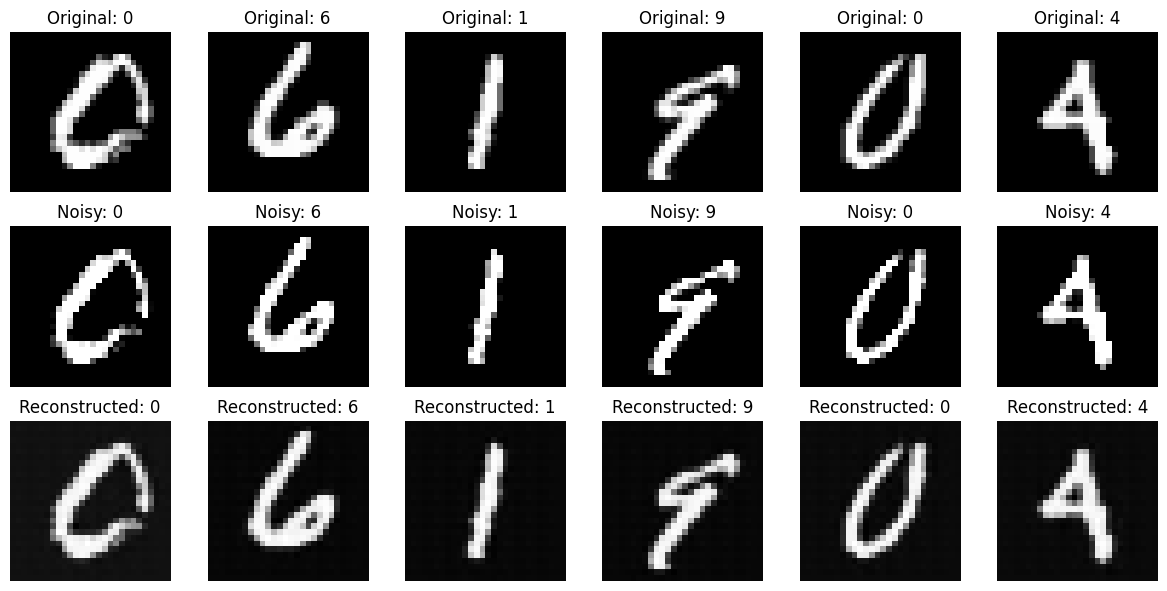

In [58]:
model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)
noisy_images = add_noise(images, noise)

with torch.no_grad():
    reconstructed = model(noisy_images)

images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(12,6))

for i in range(6):

    # ---- Original ----
    plt.subplot(3, 6, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Original: {labels[i].item()}")
    plt.axis("off")

    # ---- Noisy ----
    plt.subplot(3, 6, i+7)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title(f"Noisy: {labels[i].item()}")
    plt.axis("off")

    # ---- Reconstructed ----
    plt.subplot(3, 6, i+13)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title(f"Reconstructed: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()